# Point cloud viz (OpenGL, interactive)

Uses **PyVista** (VTK/OpenGL). Install: `pip install pyvista OpenEXR`

- **Which EXR?** The depth EXR is read from the annotation: `ann["depth_path"]`. So it's the file linked by `ANN_PATH` (e.g. `.../lpy_envy_00000_shot01.json` → `.../lpy_envy_00000_shot01.exr`). You can override with `DEPTH_PATH` in the next cell.
- **Interactive:** Backend `"none"` opens a separate window (rotate/zoom/pan with mouse). For in-notebook widget use `"trame"` or `"panel"`.

In [ ]:
# === Config ===
# Annotation path: depth EXR path is read from ann["depth_path"]
ANN_PATH = "../Data/ann_5/bark_brown/lpy_envy_00000/lpy_envy_00000_shot02.json"
# Optional: set to a path to force a specific EXR (overrides annotation). Use .. (two dots) for parent dir.
DEPTH_PATH = None  # e.g. "../Data/depth_5/bark_brown/lpy_envy_00000/lpy_envy_00000_shot02.exr"
MAX_DISTANCE = 5.0  # meters
# Backend: "none" = separate interactive window (rotate/zoom/pan). "trame" or "panel" = in-notebook
PV_BACKEND = "none"

import json
import numpy as np

try:
    import OpenEXR
    import Imath
except ImportError:
    raise ImportError("Install: pip install OpenEXR")

import pyvista as pv
pv.set_jupyter_backend(PV_BACKEND)

: 

In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 50.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


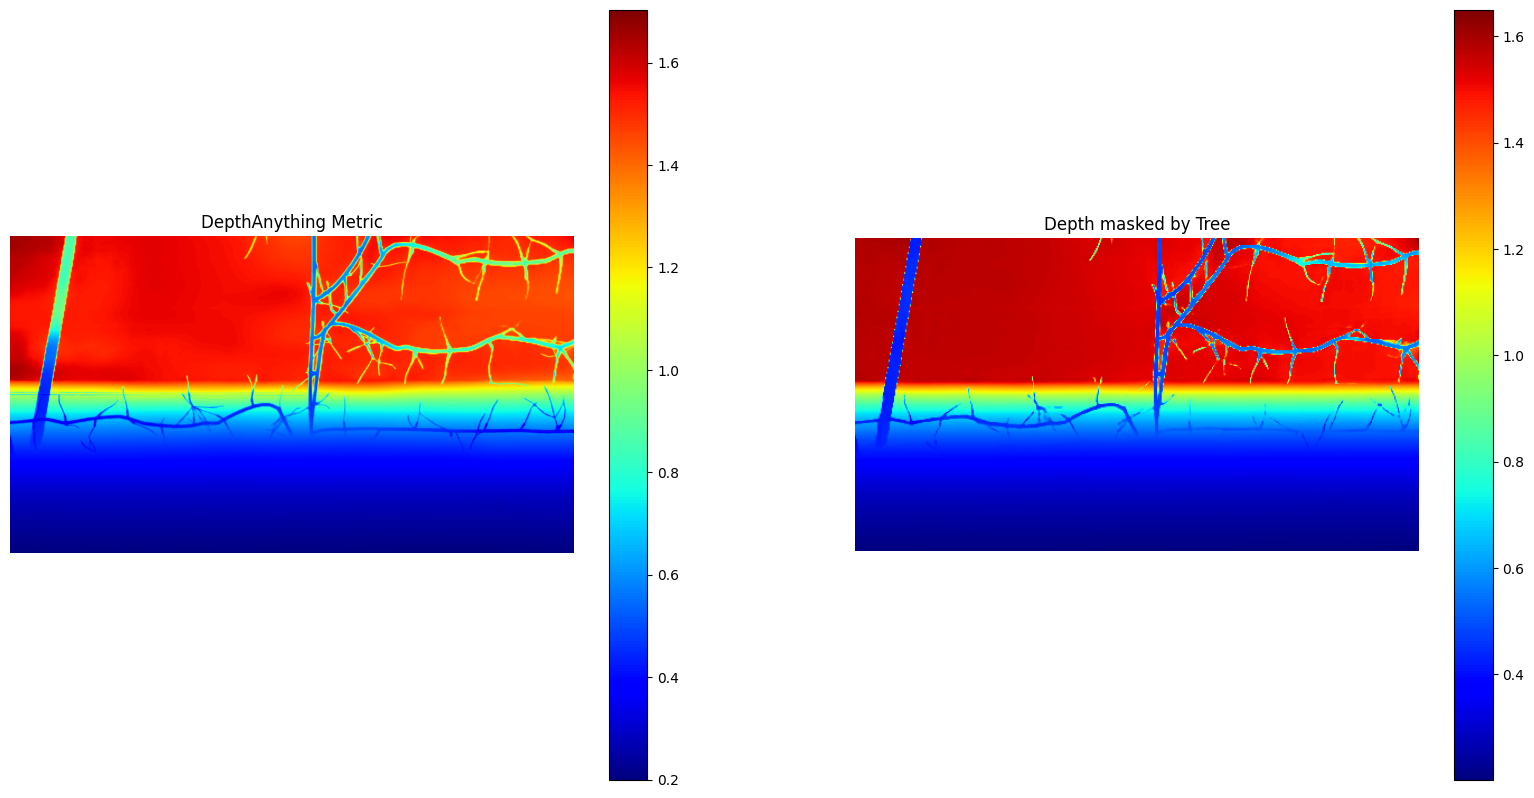

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load depth from depth_anythingv3_relative

DPM = "/nfs/stak/users/sanchej7/hpc-share/Computer_Vision/Data/trunk_spurs/depth_fused/bark_brown/lpy_envy_00000/lpy_envy_00000_shot01_fused.npy"
DPM2 = "/nfs/stak/users/sanchej7/hpc-share/Computer_Vision/Data/trunk_spurs/depth_anythingv3_relative/bark_brown/lpy_envy_00000/lpy_envy_00000_shot01.npy"
DPM = np.load(DPM)
DPM2 = np.load(DPM2)

#resizing the Depthanythingv3 metric output to the same as GT
#DPM_up = cv2.resize(DPM, (1920, 1080), interpolation=cv2.INTER_LINEAR)



# -------- Plot --------
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.imshow(DPM, cmap="jet")
plt.title("DepthAnything Metric")
plt.axis("off")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(DPM2, cmap="jet")
plt.title("Depth masked by Tree")
plt.axis("off")
plt.colorbar()

plt.show()



GT: /nfs/stak/users/sanchej7/hpc-share/Computer_Vision/Data/full_trunk/depth/bark_brown/lpy_envy_00000/box_cam7/lpy_envy_00000_shot03.npy
Box mask: /nfs/stak/users/sanchej7/hpc-share/Computer_Vision/Data/full_trunk/box_mask/bark_brown/lpy_envy_00000/box_cam7/lpy_envy_00000_shot03_box_0001.png
Tree mask: /nfs/stak/users/sanchej7/hpc-share/Computer_Vision/Data/full_trunk/mask/bark_brown/lpy_envy_00000/box_cam7/lpy_envy_00000_shot03_c_tree_0001.png


libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate


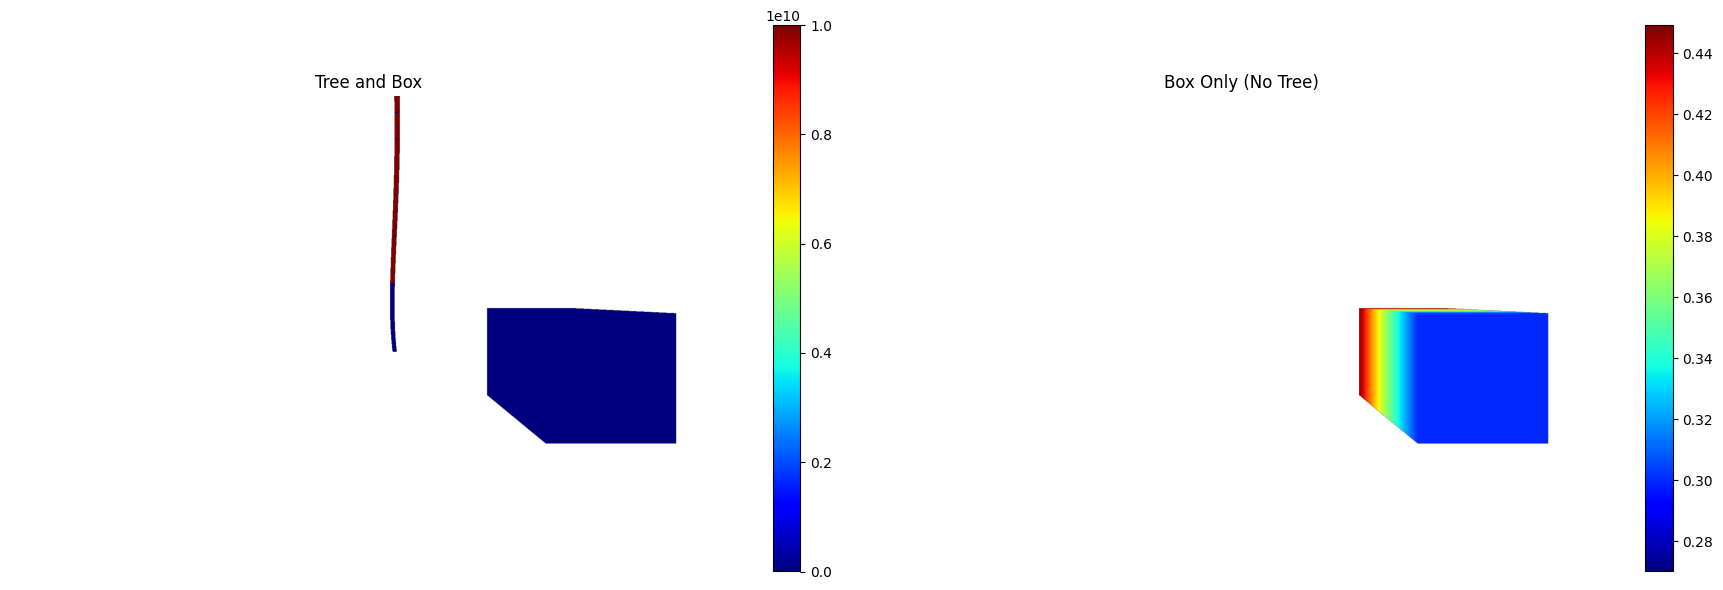

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import os

RGB_PATH = "/nfs/stak/users/sanchej7/hpc-share/Computer_Vision/Data/full_trunk/rgb/bark_brown/lpy_envy_00000/box_cam7/lpy_envy_00000_shot03.png"

# --- GT depth ---
GT_DEPTH_PATH = RGB_PATH.replace("/rgb/", "/depth/").replace(".png", ".npy")

# --- Box mask ---
BOX_MASK_PATH = RGB_PATH.replace("/rgb/", "/box_mask/").replace(
    ".png", "_box_0001.png"
)

# --- Tree mask ---
TREE_MASK_PATH = RGB_PATH.replace("/rgb/", "/mask/").replace(
    ".png", "_c_tree_0001.png"
)


# ---- Load ----
gt_depth = np.load(GT_DEPTH_PATH)

mask_box  = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE) > 0
mask_tree = cv2.imread(MASK_PATH_TREE, cv2.IMREAD_GRAYSCALE) > 0

# ---- Combine Masks ----
tree_and_box = mask_tree + mask_box
box_only    = mask_box & (~mask_tree)

# ---- Apply ----
depth_tree_in_box = np.where(tree_and_box, gt_depth, np.nan)
depth_box_only    = np.where(box_only, gt_depth, np.nan)

# ---- Consistent scale ----
vmin1 = np.nanmax(depth_tree_in_box)
vmax1 = np.nanmin(depth_tree_in_box)

vmin2 = np.nanmax(depth_box_only)
vmax2 = np.nanmin(depth_box_only)
# ---- Plot ----
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
plt.imshow(depth_tree_in_box, cmap="jet", vmin=vmin1, vmax=vmax1)
plt.title("Tree and Box")
plt.axis("off")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(depth_box_only, cmap="jet", vmin=vmin2, vmax=vmax2)
plt.title("Box Only (No Tree)")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

Testing Depthanythingv2Pro vs DepthV3

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =======================
# CHANGE TREE / SHOT HERE
# =======================
TREE_ID = "lpy_envy_00000"
SHOT = "shot01"

TARGET = 170
CUTOFF = 3
# =======================

rgb_path = f"/home/joses/Computer_Vision/Data/rgb/{TREE_ID}/{TREE_ID}_{SHOT}.png"
pro_path = f"/home/joses/Computer_Vision/One-Look-is-Enough/output/New_Dataset/{TREE_ID}_{SHOT}.png"

# -------- Load RGB --------
rgb_bgr = cv2.imread(rgb_path)
rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)

# -------- Load PRO --------
pro = cv2.imread(pro_path, cv2.IMREAD_UNCHANGED)

# Display version
if pro.ndim == 3:
    if pro.shape[2] == 4:
        pro_disp = cv2.cvtColor(pro[:, :, :3], cv2.COLOR_BGR2RGB)
        pro_gray = cv2.cvtColor(pro[:, :, :3], cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        pro_disp = cv2.cvtColor(pro, cv2.COLOR_BGR2RGB)
        pro_gray = cv2.cvtColor(pro, cv2.COLOR_BGR2GRAY).astype(np.float32)
else:
    pro_disp = pro
    pro_gray = pro.astype(np.float32)

# -------- Shape check --------
if rgb.shape[:2] != pro_gray.shape:
    raise ValueError("RGB and PRO size mismatch")

# -------- Masks --------
mask_pm2 = (np.abs(pro_gray - TARGET) <= CUTOFF).astype(np.uint8)
mask_plus2 = (pro_gray >= TARGET + CUTOFF).astype(np.uint8)

mask_pm2_vis = mask_pm2 * 255
mask_plus2_vis = mask_plus2 * 255

# -------- Plot 4 Panels --------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0,0].imshow(rgb)
axs[0,0].set_title("Original RGB")
axs[0,0].axis("off")

axs[0,1].imshow(pro_disp, cmap="gray" if pro_disp.ndim == 2 else None)
axs[0,1].set_title("Original PRO PNG")
axs[0,1].axis("off")

axs[1,0].imshow(mask_pm2_vis, cmap="gray")
axs[1,0].set_title(f"Mask: TARGET ± {CUTOFF}")
axs[1,0].axis("off")

axs[1,1].imshow(mask_plus2_vis, cmap="gray")
axs[1,1].set_title(f"Mask: ≥ TARGET + {CUTOFF}")
axs[1,1].axis("off")

plt.tight_layout()
plt.show()

print("PRO range:", pro_gray.min(), pro_gray.max())
print("Matched ±2:", mask_pm2.sum())
print("Matched +2:", mask_plus2.sum())


[ WARN:0@13.654] global loadsave.cpp:278 findDecoder imread_('/home/joses/Computer_Vision/Data/rgb/lpy_envy_00000/lpy_envy_00000_shot01.png'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


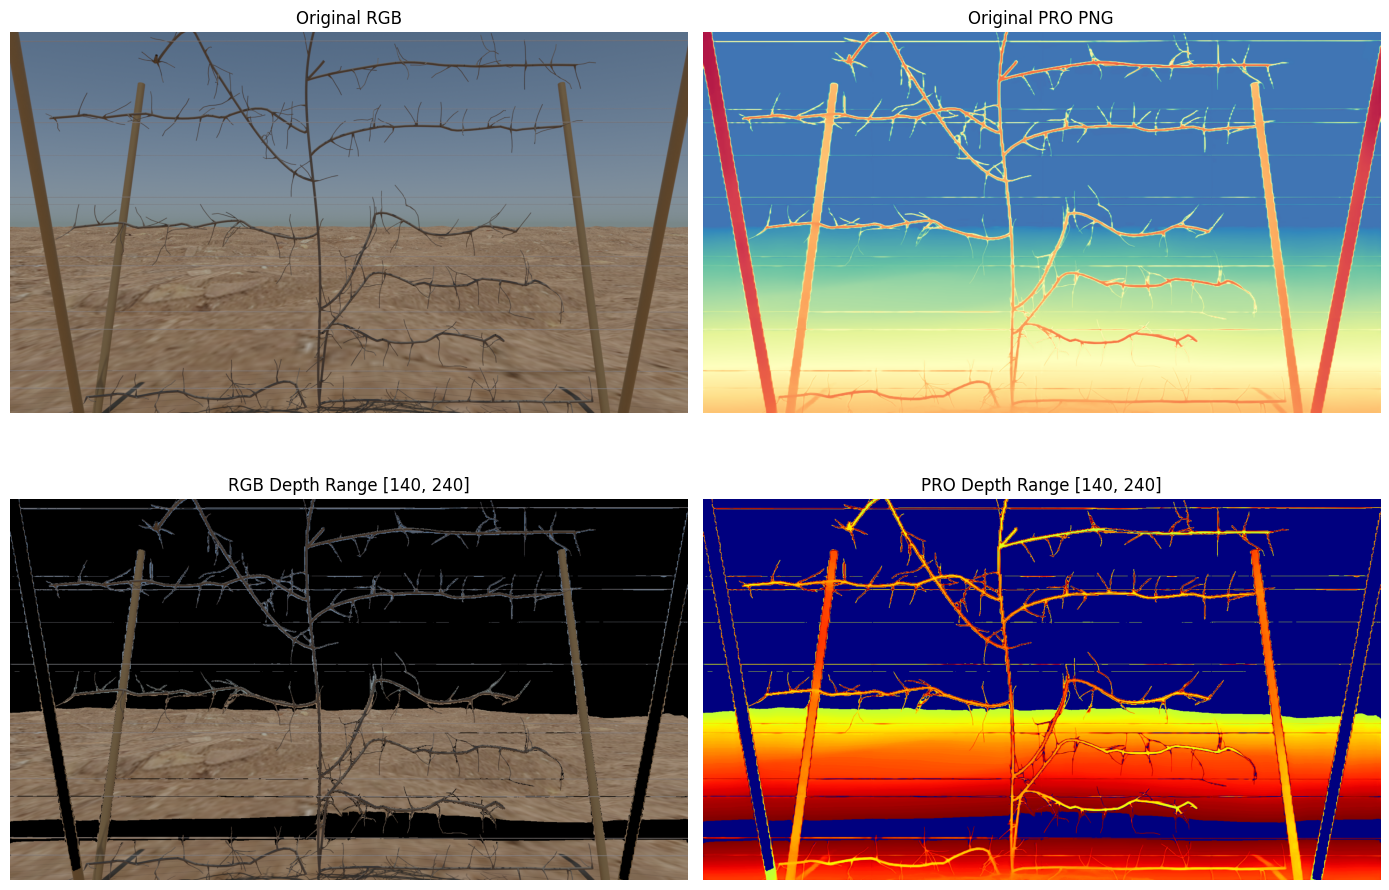

PRO range: 55.0 247.0
Matched ±2: 49218
Matched +2: 720064


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =======================
# CHANGE TREE / SHOT HERE
# =======================
TREE_ID = "lpy_envy_00000"
SHOT = "shot02"

DEPTH_MIN = 140   
DEPTH_MAX = 240 
# =======================

rgb_path = f"/home/joses/Computer_Vision/Data/rgb/{TREE_ID}/{TREE_ID}_{SHOT}.png"
pro_path = f"/home/joses/Computer_Vision/One-Look-is-Enough/output/New_Dataset/{TREE_ID}_{SHOT}.png"

# -------- Load RGB --------
rgb_bgr = cv2.imread(rgb_path)
rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)

# -------- Load PRO --------
pro = cv2.imread(pro_path, cv2.IMREAD_UNCHANGED)

# Display version
if pro.ndim == 3:
    if pro.shape[2] == 4:
        pro_disp = cv2.cvtColor(pro[:, :, :3], cv2.COLOR_BGR2RGB)
        pro_gray = cv2.cvtColor(pro[:, :, :3], cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        pro_disp = cv2.cvtColor(pro, cv2.COLOR_BGR2RGB)
        pro_gray = cv2.cvtColor(pro, cv2.COLOR_BGR2GRAY).astype(np.float32)
else:
    pro_disp = pro
    pro_gray = pro.astype(np.float32)

# -------- Shape check (no resizing) --------
if rgb.shape[:2] != pro_gray.shape:
    raise ValueError(f"RGB and PRO size mismatch: RGB {rgb.shape[:2]} vs PRO {pro_gray.shape}")

# -------- Masks (computed from PRO values) --------
range_mask = (pro_gray >= DEPTH_MIN) & (pro_gray <= DEPTH_MAX)

# -------- Optional: Clip RGB using masks --------
clip_rgb = np.zeros_like(rgb)
clip_rgb[range_mask] = rgb[range_mask]

clip_pro = np.zeros_like(pro_gray)
clip_pro[range_mask] = pro_gray[range_mask]


# -------- Plot 4 Panels --------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0,0].imshow(rgb)
axs[0,0].set_title("Original RGB")
axs[0,0].axis("off")

axs[0,1].imshow(pro_disp, cmap="gray" if (isinstance(pro_disp, np.ndarray) and pro_disp.ndim == 2) else None)
axs[0,1].set_title("Original PRO PNG")
axs[0,1].axis("off")

axs[1,0].imshow(clip_rgb)
axs[1,0].set_title(f"RGB Depth Range [{DEPTH_MIN}, {DEPTH_MAX}]")
axs[1,0].axis("off")

axs[1,1].imshow(clip_pro, cmap="jet")
axs[1,1].set_title(f"PRO Depth Range [{DEPTH_MIN}, {DEPTH_MAX}]")
axs[1,1].axis("off")


plt.tight_layout()
plt.show()

print("PRO range:", float(pro_gray.min()), float(pro_gray.max()))
print("Matched ±2:", int(mask_pm2.sum()))
print("Matched +2:", int(mask_plus2.sum()))

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

TREE_ID = "lpy_envy_00000"
SHOT = "shot01"

pro_path  = f"/home/joses/Computer_Vision/One-Look-is-Enough/output/New_Dataset/{TREE_ID}_{SHOT}.png"
mask_path = f"/home/joses/Computer_Vision/Data/mask/{TREE_ID}/{TREE_ID}_{SHOT}_tree_0001.png"


# -------- Load RGB --------
rgb = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)

# -------- Load PRO --------
pro = cv2.imread(pro_path, cv2.IMREAD_UNCHANGED)

# Convert PRO to display + grayscale
if pro.ndim == 3:
    if pro.shape[2] == 4:
        pro_disp = cv2.cvtColor(pro[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        pro_disp = cv2.cvtColor(pro, cv2.COLOR_BGR2RGB)
else:
    pro_disp = pro

# -------- Load Mask --------
mask = Image.open(mask_path).convert("L")
mask = np.array(mask)

# Convert to boolean
mask_bool = mask > 130

# -------- Shape check --------
if mask_bool.shape != pro_disp.shape[:2]:
    raise ValueError("Mask and PRO mismatch")

# -------- Apply Mask --------
clip_pro = np.zeros_like(pro_disp)
clip_pro[mask_bool] = pro_disp[mask_bool]

# -------- Plot --------
plt.figure(figsize=(20,10))


plt.subplot(1,2,1)
plt.imshow(pro_disp, cmap="gray" if pro_disp.ndim==2 else None)
plt.title("Original PRO PNG")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clip_pro, cmap="gray" if clip_pro.ndim==2 else None)
plt.title("PRO masked by Tree Mask")
plt.axis("off")

plt.show()


NameError: name 'rgb_path' is not defined

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

TREE_ID = "lpy_envy_00000"
SHOT = "shot01"

depth_path = f"../Data/depth_anythingv3_metric/{TREE_ID}/{TREE_ID}_{SHOT}.npy"
mask_path  = f"..Data/mask/{TREE_ID}/{TREE_ID}_{SHOT}_tree_0001.png"

# -------- Load Depth --------
DPM = np.load(depth_path).astype(np.float32)

# -------- Load Mask --------
mask = Image.open(mask_path).convert("L")
mask = np.array(mask)

mask_bool = mask > 130

print("Depth shape:", DPM.shape)
print("Mask shape:", mask_bool.shape)

# -------- Resize Mask to Depth --------
if mask_bool.shape != DPM.shape:
    mask_bool = cv2.resize(
        mask_bool.astype(np.uint8),
        (DPM.shape[1], DPM.shape[0]),
        interpolation=cv2.INTER_NEAREST
    ).astype(bool)

# -------- Apply Mask --------
clip_depth = np.where(mask_bool, DPM, np.nan)

print("Masked depth stats:",
          "min:", np.nanmin(clip_depth),
          "max:", np.nanmax(clip_depth),
          "mean:", np.nanmean(clip_depth),
          "median:", np.nanmedian(clip_depth))
# -------- Plot --------
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.imshow(DPM, cmap="jet")
plt.title("DepthAnything Metric")
plt.axis("off")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(clip_depth, cmap="jet")
plt.title("Depth masked by Tree")
plt.axis("off")
plt.colorbar()

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '../Data/depth_anythingv3_metric/lpy_envy_00000/lpy_envy_00000_shot01.npy'

Frame 1: alpha=-0.856187, beta=3.1832, RMSE=2.2832, MAE=0.6839
Frame 2: alpha=7.613916, beta=-0.9916, RMSE=1.1653, MAE=0.4568
Frame 3: alpha=11.321785, beta=-4.3200, RMSE=3.5487, MAE=1.3972
Frame 4: alpha=24.670988, beta=-13.9862, RMSE=3.8698, MAE=1.6176
Frame 5: alpha=32.041961, beta=-16.5736, RMSE=4.2809, MAE=2.2100
Frame 6: alpha=87.229783, beta=-22.8143, RMSE=6.0557, MAE=3.3366

GLOBAL alpha,beta: 1.7489980149597881 1.9476539908579913
GLOBAL rmse,mae: 4.318971960363808 1.831610063072664


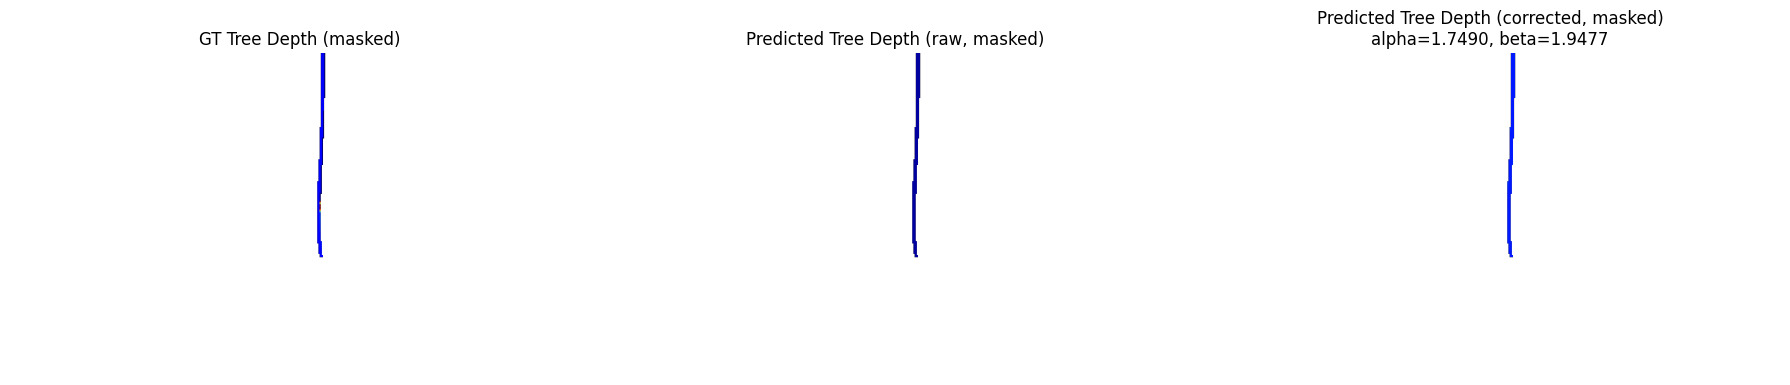

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import OpenEXR
import Imath


# -------------------------
# Utility Functions
# -------------------------

def load_exr(path: str):
    exr_file = OpenEXR.InputFile(path)
    header = exr_file.header()
    dw = header['dataWindow']
    wid = dw.max.x - dw.min.x + 1
    ht = dw.max.y - dw.min.y + 1
    pt = Imath.PixelType(Imath.PixelType.FLOAT)
    Z = np.frombuffer(exr_file.channel('ViewLayer.Depth.Z', pt), dtype = np.float32).reshape(ht, wid)
    exr_file.close()
    return Z


def load_mask(path):
    return np.array(Image.open(path).convert("L"))


def arr_to_bool(arr):
    return arr > 130


def clean_depth(d, max_depth=50.0):
    d = d.copy()
    d[~np.isfinite(d)] = 0
    d[d > max_depth] = 0
    return d


def get_depth_mask(DPM, DGT, tree_mask):
    return (tree_mask) & (DPM > 0) & (DGT > 0)


def fit_alpha_beta(x, y):
    A = np.stack([x, np.ones_like(x)], axis=1)
    sol, *_ = np.linalg.lstsq(A, y, rcond=None)
    return sol[0], sol[1]


def eval_fit(x, y, alpha, beta):
    y_pred = alpha * x + beta
    err = y - y_pred
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    return rmse, mae


# -------------------------
# Load Data
# -------------------------

TREE = "lpy_envy_00000"

shots = ["shot01", "shot02", "shot03", "shot04","shot05", "shot06"]

frames = []

for i, shot in enumerate(shots, 1):

    # --- Load predicted ---
    DPM = np.load(f"../Data/full_trunk/depth_anythingv3_relative/bark_brown/{TREE}/{TREE}_{shot}.npy")

    # --- Load GT ---
    DGT = load_exr(f"../Data/full_trunk/depth/bark_brown/{TREE}/{TREE}_{shot}.exr")

    # --- Downsample GT ---
    DGT_dn = cv2.resize(DGT, (504, 280), interpolation=cv2.INTER_AREA)
    DGT_dn = clean_depth(DGT_dn)

    # --- Load Mask ---
    mask = load_mask(f"../Data/full_trunk/mask/bark_brown/{TREE}/{TREE}_{shot}_c_tree_000{i}.png")

    mask_dn = cv2.resize(
        mask,
        (504, 280),
        interpolation=cv2.INTER_NEAREST
    )

    bool_mask = arr_to_bool(mask_dn)

    frames.append((DPM, DGT_dn, bool_mask))


# -------------------------
# Joint Fit
# -------------------------

xs, ys = [], []

for i, (DPM, DGT, mask) in enumerate(frames):

    quality_mask = get_depth_mask(DPM, DGT, mask)

    x = DPM[quality_mask].astype(np.float64)
    y = DGT[quality_mask].astype(np.float64)

    alpha, beta = fit_alpha_beta(x, y)
    rmse, mae = eval_fit(x, y, alpha, beta)

    print(f"Frame {i+1}: alpha={alpha:.6f}, beta={beta:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

    xs.append(x)
    ys.append(y)


# ---- Global Fit ----
x_all = np.concatenate(xs)
y_all = np.concatenate(ys)

alphaG, betaG = fit_alpha_beta(x_all, y_all)
rmseG, maeG = eval_fit(x_all, y_all, alphaG, betaG)

print("\nGLOBAL alpha,beta:", alphaG, betaG)
print("GLOBAL rmse,mae:", rmseG, maeG)


# -------------------------
# Visualization Example
# -------------------------

DPM_1, DGT_1, mask_1 = frames[0]

# Use GLOBAL fit (or swap to per-frame alpha/beta if you want)
DPM_corr_1 = alphaG * DPM_1 + betaG
DPM_corr_1 = clean_depth(DPM_corr_1, max_depth=50.0)  # optional clamp

# Mask them (tree only)
dgt_masked = np.where(mask_1, DGT_1, np.nan)
dpm_masked = np.where(mask_1, DPM_1, np.nan)
dpm_corr_masked = np.where(mask_1, DPM_corr_1, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(dgt_masked, cmap="jet", vmin=0, vmax=20)
axes[0].set_title("GT Tree Depth (masked)")
axes[0].axis("off")

axes[1].imshow(dpm_masked, cmap="jet", vmin=0, vmax=20)
axes[1].set_title("Predicted Tree Depth (raw, masked)")
axes[1].axis("off")

# Pick a vmax that matches GT range if you want apples-to-apples
axes[2].imshow(dpm_corr_masked, cmap="jet", vmin=0, vmax=20)
axes[2].set_title(f"Predicted Tree Depth (corrected, masked)\nalpha={alphaG:.4f}, beta={betaG:.4f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [25]:
TREE = "lpy_envy_00000"
shots = ["shot01", "shot02", "shot03"]

frames_PRO = []
frames_DPM = []

for i, shot in enumerate(shots, 1):

    # ---------------- PRO ----------------
    pro = cv2.imread(
        f"../One-Look-is-Enough/output/New_Dataset/{TREE}_{shot}.png",
        cv2.IMREAD_UNCHANGED
    )

    if pro.ndim == 3:
        PRO = cv2.cvtColor(pro[:,:,:3], cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        PRO = pro.astype(np.float32)

    PRO = cv2.resize(PRO, (504, 280), interpolation=cv2.INTER_LINEAR)


    # ---------------- DepthAnything ----------------
    DPM = np.load(
        f"../Data/depth_anythingv3_metric/{TREE}/{TREE}_{shot}.npy"
    ).astype(np.float32)


    # ---------------- Ground Truth ----------------
    DGT = load_exr(
        f"../Data/depth/{TREE}/{TREE}_{shot}.exr"
    )

    DGT_dn = cv2.resize(DGT, (504, 280), interpolation=cv2.INTER_AREA)
    DGT_dn = clean_depth(DGT_dn)


    # ---------------- Mask ----------------
    mask = load_mask(
        f"../Data/mask/{TREE}/{TREE}_{shot}_tree_000{i}.png"
    )

    mask_dn = cv2.resize(mask, (504, 280), interpolation=cv2.INTER_NEAREST)
    bool_mask = arr_to_bool(mask_dn)


    frames_PRO.append((PRO, DGT_dn, bool_mask))
    frames_DPM.append((DPM, DGT_dn, bool_mask))


# ========================================
# Evaluation Function
# ========================================

def evaluate_model(frames, label):

    xs, ys = [], []

    print(f"\n===== {label} Evaluation =====")

    for i, (DEPTH, GT, MASK) in enumerate(frames):

        quality_mask = get_depth_mask(DEPTH, GT, MASK)

        x = DEPTH[quality_mask].astype(np.float64)
        y = GT[quality_mask].astype(np.float64)

        alpha, beta = fit_alpha_beta(x, y)
        rmse, mae = eval_fit(x, y, alpha, beta)

        print(
            f"[{label}] Frame {i+1}: "
            f"alpha={alpha:.6f}, "
            f"beta={beta:.4f}, "
            f"RMSE={rmse:.4f}, "
            f"MAE={mae:.4f}"
        )

        xs.append(x)
        ys.append(y)

    # ---- Global Fit ----
    x_all = np.concatenate(xs)
    y_all = np.concatenate(ys)

    alphaG, betaG = fit_alpha_beta(x_all, y_all)
    rmseG, maeG = eval_fit(x_all, y_all, alphaG, betaG)

    print(f"\n[{label} GLOBAL] alpha,beta:", alphaG, betaG)
    print(f"[{label} GLOBAL] rmse,mae:", rmseG, maeG)

    return alphaG, betaG, rmseG, maeG


# ========================================
# Run Both Models
# ========================================

alpha_PRO, beta_PRO, rmse_PRO, mae_PRO = evaluate_model(frames_PRO, "PRO")
alpha_DPM, beta_DPM, rmse_DPM, mae_DPM = evaluate_model(frames_DPM, "DepthAnything")


# ========================================
# Final Comparison
# ========================================

print("\n=========== MODEL COMPARISON ===========")

print(f"PRO RMSE : {rmse_PRO:.4f}")
print(f"DPM RMSE : {rmse_DPM:.4f}")

print(f"PRO MAE  : {mae_PRO:.4f}")
print(f"DPM MAE  : {mae_DPM:.4f}")




===== PRO Evaluation =====
[PRO] Frame 1: alpha=-0.218224, beta=57.1579, RMSE=4.1330, MAE=2.0944
[PRO] Frame 2: alpha=0.012067, beta=4.8331, RMSE=7.2290, MAE=4.2240
[PRO] Frame 3: alpha=0.057141, beta=-1.4219, RMSE=5.3231, MAE=2.7792

[PRO GLOBAL] alpha,beta: 0.002840672398636086 6.601007767532108
[PRO GLOBAL] rmse,mae: 6.72840669919106 4.042652254978015

===== DepthAnything Evaluation =====
[DepthAnything] Frame 1: alpha=0.037134, beta=6.5258, RMSE=6.6256, MAE=3.8247
[DepthAnything] Frame 2: alpha=0.103118, beta=6.7276, RMSE=7.2277, MAE=4.2663
[DepthAnything] Frame 3: alpha=0.337558, beta=6.5141, RMSE=5.9955, MAE=3.8452

[DepthAnything GLOBAL] alpha,beta: 0.0496030091025602 6.935598258599059
[DepthAnything GLOBAL] rmse,mae: 6.727105058295126 4.062138300394219

=========== MODEL COMPARISON ===========
PRO RMSE : 6.7284
DPM RMSE : 6.7271
PRO MAE  : 4.0427
DPM MAE  : 4.0621


In [8]:
TREE = "lpy_envy_00000"
shots = ["shot01", "shot02", "shot03"]

for i, shot in enumerate(shots, 1):

    # ---------------- Load GT ----------------
    DGT = load_exr(f"../Data/depth/{TREE}/{TREE}_{shot}.exr")
    DGT_dn = cv2.resize(DGT, (504, 280), interpolation=cv2.INTER_AREA)
    DGT_dn = clean_depth(DGT_dn)

    # ---------------- Load Mask ----------------
    mask = load_mask(f"../Data/mask/{TREE}/{TREE}_{shot}_tree_000{i}.png")
    mask_dn = cv2.resize(mask, (504, 280), interpolation=cv2.INTER_NEAREST)
    bool_mask = arr_to_bool(mask_dn)

    # ---------------- Load PRO ----------------
    pro = cv2.imread(
        f"../One-Look-is-Enough/output/New_Dataset/{TREE}_{shot}.png",
        cv2.IMREAD_UNCHANGED
    )

    if pro.ndim == 3:
        PRO = cv2.cvtColor(pro[:,:,:3], cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        PRO = pro.astype(np.float32)

    PRO = cv2.resize(PRO, (504, 280), interpolation=cv2.INTER_LINEAR)

    # ---------------- Load DepthAnything ----------------
    DPM = np.load(
        f"../Data/depth_anythingv3_metric/{TREE}/{TREE}_{shot}.npy"
    ).astype(np.float32)

    # ---------------- Apply Calibration ----------------
    PRO_corr = alpha_PRO * PRO + beta_PRO
    DPM_corr = alpha_DPM * DPM + beta_DPM

    # ---------------- Apply Tree Mask ----------------
    GT_tree = np.where(bool_mask, DGT_dn, np.nan)
    PRO_tree = np.where(bool_mask, PRO_corr, np.nan)
    DPM_tree = np.where(bool_mask, DPM_corr, np.nan)

    # ---------------- Plot ----------------
    fig, axes = plt.subplots(1, 3, figsize=(18,6))

    axes[0].imshow(GT_tree, cmap="jet", vmin=0, vmax=5)
    axes[0].set_title("GT Tree Depth")
    axes[0].axis("off")

    axes[1].imshow(PRO_tree, cmap="jet", vmin=0, vmax=5)
    axes[1].set_title("PRO Corrected Depth")
    axes[1].axis("off")

    axes[2].imshow(DPM_tree, cmap="jet", vmin=0, vmax=5)
    axes[2].set_title("DepthAnything Corrected Depth")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


../Data/depth/lpy_envy_00000/lpy_envy_00000_shot01.exr: (EXR_ERR_FILE_ACCESS) Unable to open file for read: No such file or directory


OSError: Unable to open '../Data/depth/lpy_envy_00000/lpy_envy_00000_shot01.exr' for read

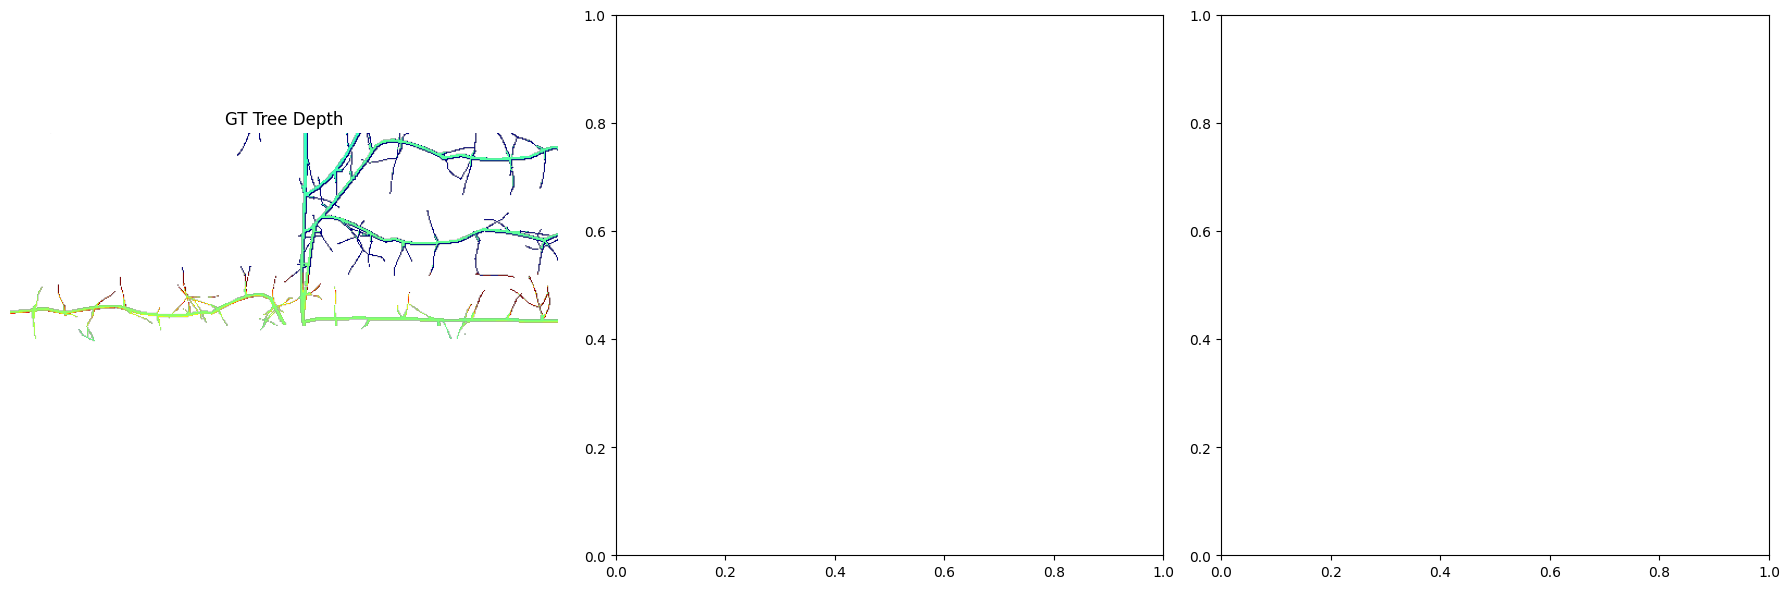

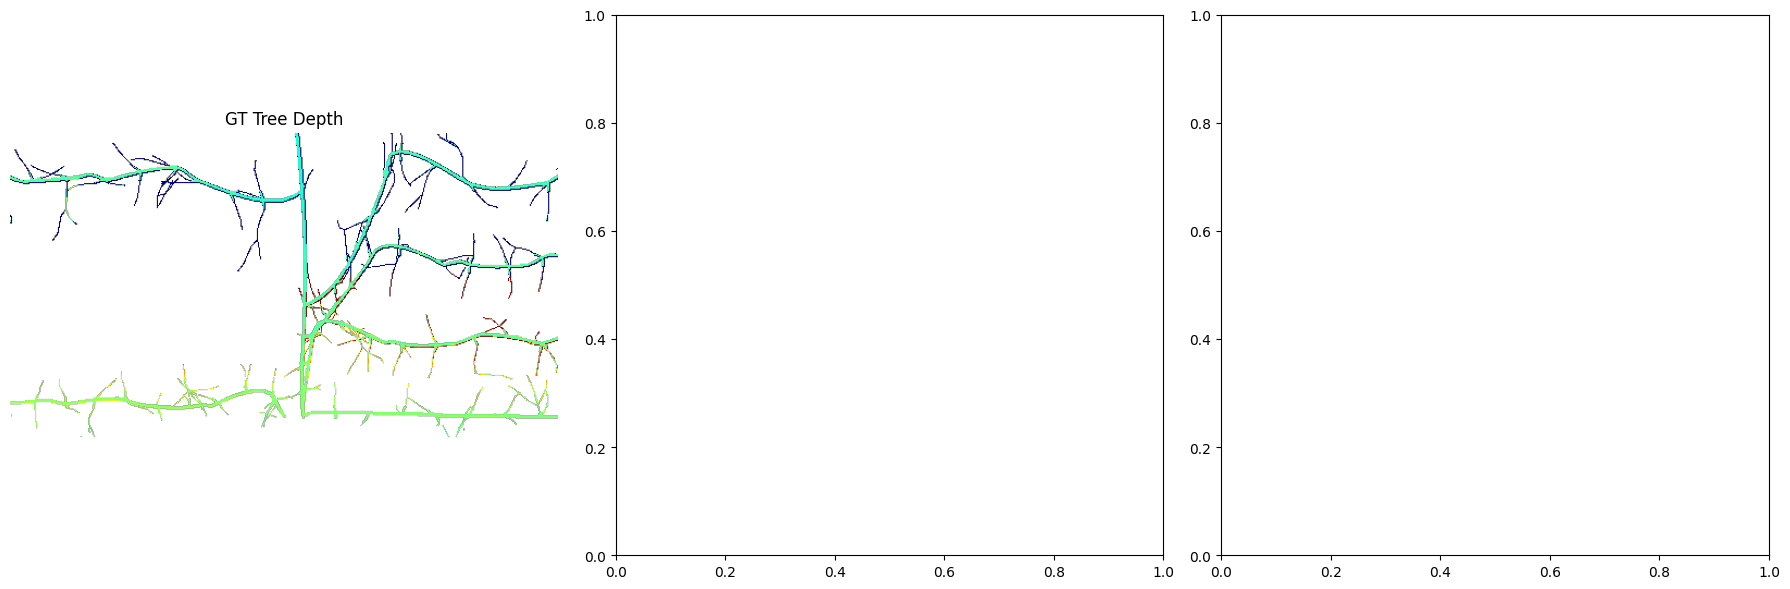

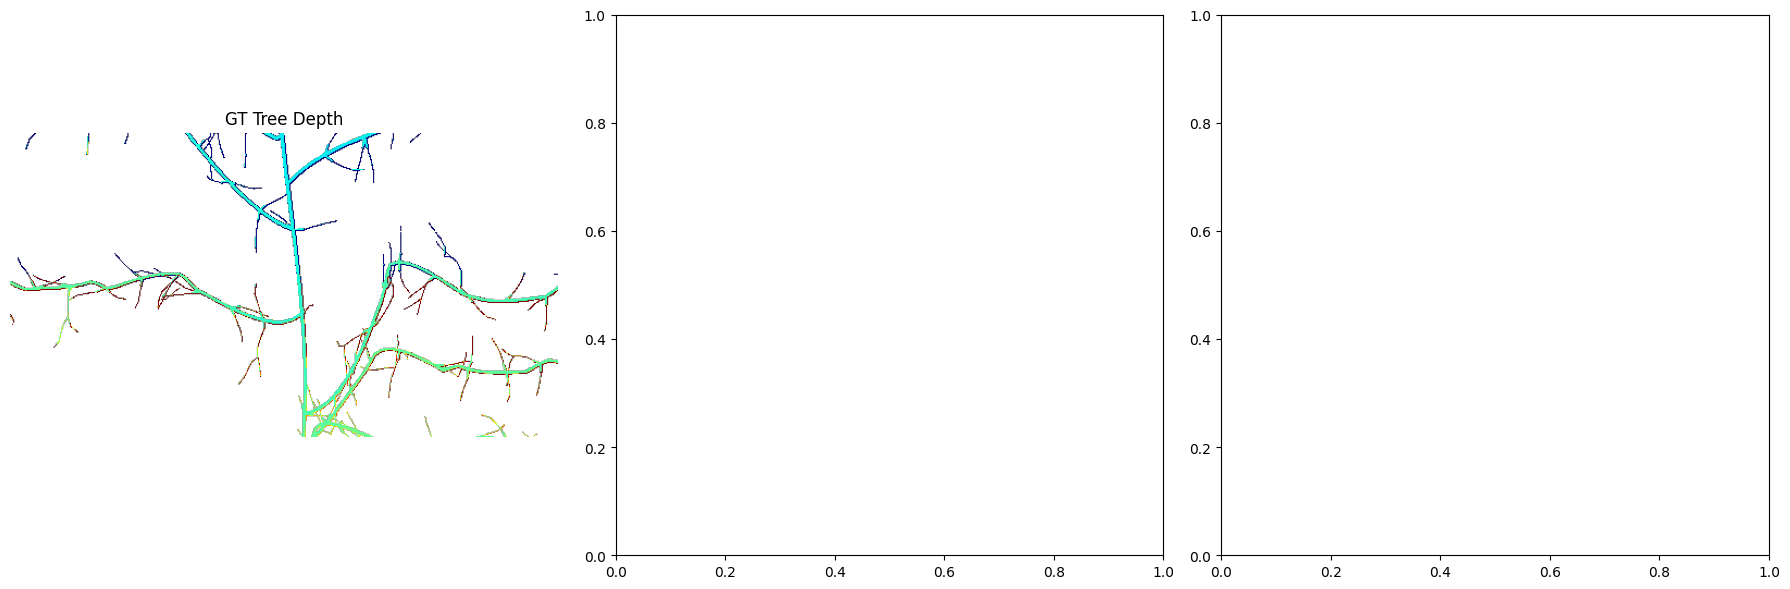

In [ ]:
TREE = "lpy_envy_00000"
shots = ["shot01", "shot02", "shot03"]

for i, shot in enumerate(shots, 1):

    # ---------------- Load GT ----------------
    DGT = load_exr(f"../Data/trunk_spurs/depth/bark_brown/{TREE}/{TREE}_{shot}.exr")
    DGT_dn = cv2.resize(DGT, (504, 280), interpolation=cv2.INTER_AREA)
    DGT_dn = clean_depth(DGT_dn)

    # ---------------- Load Mask ----------------
    mask = load_mask(f"../Data/trunk_spurs/mask/bark_brown/{TREE}/{TREE}_{shot}_c_tree_000{i}.png")
    mask_dn = cv2.resize(mask, (504, 280), interpolation=cv2.INTER_NEAREST)
    bool_mask = arr_to_bool(mask_dn)

    

    # ---------------- Load DepthAnything ----------------
    DPM = np.load(
        f"../Data/trunk_spurs/depth_anythingv3_relative/bark_brown/{TREE}/{TREE}_{shot}.npy"
    ).astype(np.float32)



    # ---------------- Apply Tree Mask ----------------
    GT_tree = np.where(bool_mask, DGT_dn, np.nan)

    DPM_tree = np.where(bool_mask, DPM, np.nan)

    # ---------------- Plot ----------------
    fig, axes = plt.subplots(1, 2, figsize=(18,6))

    axes[0].imshow(GT_tree, cmap="jet", vmin=0, vmax=5)
    axes[0].set_title("GT Tree Depth")
    axes[0].axis("off")
     
    axes[1].imshow(DPM, cmap="jet", vmin=0, vmax=5)
    axes[1].set_title("GT Tree Depth")
    axes[1].axis("off")



    plt.tight_layout()
    plt.show()


/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


../Data/depth/lpy_envy_00000/lpy_envy_00000_shot01.exr: (EXR_ERR_FILE_ACCESS) Unable to open file for read: No such file or directory


OSError: Unable to open '../Data/depth/lpy_envy_00000/lpy_envy_00000_shot01.exr' for read

In [44]:
import numpy as np
import cv2
import json
import open3d as o3d
import matplotlib.pyplot as plt


# ==================================================
# CONFIG
# ==================================================

TREE = "lpy_envy_00000"
SHOT = "shot01"

ANN_PATH = f"../Data/ann/{TREE}/{TREE}_{SHOT}.json"

WIDTH = 504
HEIGHT = 280
MAX_DISTANCE = 5

USE_DEPTHANYTHING = True   # Toggle here


# ==================================================
# Point Cloud Generator (Scaled Intrinsics)
# ==================================================

def euler_xyz_to_R(e):
    rx, ry, rz = float(e[0]), float(e[1]), float(e[2])
    cx, sx = np.cos(rx), np.sin(rx)
    cy, sy = np.cos(ry), np.sin(ry)
    cz, sz = np.cos(rz), np.sin(rz)
    return np.array([
        [cy * cz, -cy * sz, sy],
        [cx * sz + sx * sy * cz, cx * cz - sx * sy * sz, -sx * cy],
        [sx * sz - cx * sy * cz, sx * cz + cx * sy * sz, cx * cy],
    ], dtype=np.float32)

def depth_to_pointcloud_world_scaledK(
    depth: np.ndarray,
    ann_path: str,
    mask_bool: np.ndarray = None,
    orig_size=(1080, 1920),   # (H0, W0) of the K in the json
    max_distance=5.0,
    color=None,
):
    with open(ann_path, "r") as f:
        ann = json.load(f)

    # intrinsics from ann (for orig_size)
    K = np.array(ann["camera"]["intrinsics"]["K"], dtype=np.float32)
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    H, W = depth.shape
    H0, W0 = orig_size

    # scale intrinsics to current depth resolution
    sx = W / W0
    sy = H / H0
    fx *= sx; fy *= sy
    cx *= sx; cy *= sy

    z = depth.astype(np.float32)
    
    if mask_bool is None:
        m = np.ones_like(z, dtype=bool)
    else:
        m = mask_bool.astype(bool)

    valid = m & np.isfinite(z) & (z > 0)
    if max_distance is not None:
        valid &= (z <= max_distance)

    if not np.any(valid):
        return o3d.geometry.PointCloud()

    u, v = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy

    pts = np.stack([x, y, z], axis=-1)[valid]  # camera coords

    # APPLY camera pose -> world coords (this is what your "normal" GT code does)
    pos = np.array(ann["camera"]["location"], dtype=np.float32)
    R = euler_xyz_to_R(ann["camera"]["rotation_euler"])
    pts = (R @ pts.T).T + pos

    # Debug: if these stds are ~0, you really did collapse
    print("pts std (x,y,z):", pts[:,0].std(), pts[:,1].std(), pts[:,2].std())
    print("pts min:", pts.min(axis=0), "max:", pts.max(axis=0), "N:", pts.shape[0])

    pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts.astype(np.float64)))
    if color is not None:
        pcd.paint_uniform_color(color)
    return pcd


def color_jet(pcd):
    pts=np.asarray(pcd.points)
    if len(pts)==0: return pcd
    z=pts[:,2]
    zn=(z-z.min())/(z.max()-z.min()+1e-8)
    pcd.colors=o3d.utility.Vector3dVector(plt.cm.jet(zn)[:,:3])
    return pcd
# ==================================================
# Load GT EXR
# ==================================================

DGT = load_exr(f"../Data/depth/{TREE}/{TREE}_{SHOT}.exr")

mask = load_mask(f"../Data/mask/{TREE}/{TREE}_{SHOT}_tree_0001.png") 

mask_bool = arr_to_bool(mask)
DGT_clean = DGT.copy().astype(np.float32)
DGT_clean[~np.isfinite(DGT_clean)] = 0
DGT_clean[DGT_clean > 50.0] = 0 

DGT_masked = np.where(mask_bool, DGT_clean, 0)


pcd_gt = depth_to_pointcloud_world_scaledK(
    DGT_masked, ANN_PATH, orig_size=(1080,1920), max_distance=5
)

#pcd_gt = depth_to_pointcloud_world_scaledK(
 #   DGT, ANN_PATH, orig_size=(1080,1920), max_distance=MAX_GT
#)
# make mask_dn match PRO shape



pcd_corr = depth_to_pointcloud_world_scaledK(
    PRO_corr,  ANN_PATH, mask_dn, orig_size=(1080,1920), max_distance=20
)

pcd_gt   = color_jet(pcd_gt)

pcd_corr = color_jet(pcd_corr)

print("GT z range:", DGT[DGT>0].min(), DGT.max())
print("PRO z range:", PRO.min(), PRO.max())
print("PRO_corr z range:", PRO_corr.min(), PRO_corr.max())


pcd_gt.translate([-3,0,0])

pcd_corr.translate([3,0,0])

o3d.visualization.draw_geometries([pcd_gt, pcd_corr], window_name="GT | PRO | PRO_corr")



pts std (x,y,z): 0.54730856 0.10646011 0.58492416
pts min: [-11.0493555  -10.03665     -0.24558643] max: [-8.616225  -9.283911   2.0206046] N: 59364
pts std (x,y,z): 0.962937 0.13843009 1.0572604
pts min: [-12.079614  -12.824902   -2.0020254] max: [ -8.004623 -12.254719   2.252145] N: 4483
GT z range: 2.22009 10000000000.0
PRO z range: 59.142857 247.0
PRO_corr z range: 6.7690134 7.3026543


In [42]:
import numpy as np
import cv2, json
import open3d as o3d
import matplotlib.pyplot as plt
from torch.distributions import Beta

# ---------------- CONFIG ----------------
TREE="lpy_envy_00000"
SHOT="shot01"
ANN_PATH=f"../Data/ann/{TREE}/{TREE}_{SHOT}.json"

GT_EXR = f"../Data/depth/{TREE}/{TREE}_{SHOT}.exr"

# >>> CHANGE THIS to your DepthAnythingV2 output path (raw depth)
DA2_PATH = f"../Data/depth_anythingv3_metric/{TREE}/{TREE}_{SHOT}.npy"  # example

# >>> Put your calibration here (from your fit against GT)
ALPHA_DA2 = alpha_DPM
BETA_DA2  = beta_DPM

USE_MASK = True
MAX_GT  = 10.0     # adjust if your scene is farther
MAX_DA2 = 10.0     # adjust if DA2 predicts farther
SEP = 3.0

# ---------------- Helpers ----------------
def euler_xyz_to_R(e):
    rx, ry, rz = map(float, e)
    cx, sx = np.cos(rx), np.sin(rx)
    cy, sy = np.cos(ry), np.sin(ry)
    cz, sz = np.cos(rz), np.sin(rz)
    return np.array([
        [cy*cz, -cy*sz, sy],
        [cx*sz + sx*sy*cz, cx*cz - sx*sy*sz, -sx*cy],
        [sx*sz - cx*sy*cz, sx*cz + cx*sy*sz, cx*cy],
    ], dtype=np.float32)

def depth_to_pcd(depth, ann_path, mask=None, orig_size=(1080,1920), max_distance=None):
    ann = json.load(open(ann_path))
    K = np.array(ann["camera"]["intrinsics"]["K"], dtype=np.float32)
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]

    H, W = depth.shape
    H0, W0 = orig_size
    sx, sy = W/W0, H/H0
    fx *= sx; fy *= sy
    cx *= sx; cy *= sy

    z = depth.astype(np.float32)

    if mask is None:
        m = np.ones_like(z, dtype=bool)
    else:
        if mask.shape != z.shape:
            raise ValueError(f"Mask shape {mask.shape} != depth shape {z.shape}")
        m = mask.astype(bool)

    valid = m & np.isfinite(z) & (z > 0)
    if max_distance is not None:
        valid &= (z <= max_distance)

    if not np.any(valid):
        return o3d.geometry.PointCloud()

    u, v = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    pts = np.stack([x, y, z], axis=-1)[valid]

    pos = np.array(ann["camera"]["location"], dtype=np.float32)
    R = euler_xyz_to_R(ann["camera"]["rotation_euler"])
    pts = (R @ pts.T).T + pos

    return o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts.astype(np.float64)))

def color_jet(pcd):
    pts = np.asarray(pcd.points)
    if len(pts) == 0:
        return pcd
    z = pts[:,2]
    zn = (z - z.min())/(z.max()-z.min()+1e-8)
    pcd.colors = o3d.utility.Vector3dVector(plt.cm.jet(zn)[:,:3])
    return pcd

# ---------------- Load GT ----------------
DGT = load_exr(GT_EXR).astype(np.float32)
DGT[~np.isfinite(DGT)] = 0
DGT[DGT > 50.0] = 0   # removes 1e10 invalids

mask_full = arr_to_bool(load_mask(f"../Data/mask/{TREE}/{TREE}_{SHOT}_tree_0001.png")) if USE_MASK else None
if USE_MASK:
    DGT = np.where(mask_full, DGT, 0)

# ---------------- Load DepthAnythingV2 ----------------
DA2 = np.load(DA2_PATH).astype(np.float32)

# Mask for DA2 resolution
mask_da2 = None
if USE_MASK:
    mask_da2 = cv2.resize(mask_full.astype(np.uint8), (DA2.shape[1], DA2.shape[0]),
                          interpolation=cv2.INTER_NEAREST).astype(bool)

DA2_corr = ALPHA_DA2 * DA2 + BETA_DA2

print("GT  shape/range:", DGT.shape, float(np.nanmin(DGT)), float(np.nanmax(DGT)))
print("DA2 shape/range:", DA2.shape, float(np.nanmin(DA2)), float(np.nanmax(DA2)))
print("DA2corr range  :", float(np.nanmin(DA2_corr)), float(np.nanmax(DA2_corr)))

# ---------------- Build clouds ----------------
pcd_gt   = color_jet(depth_to_pcd(DGT,      ANN_PATH, mask=mask_full if USE_MASK else None, max_distance=MAX_GT))
pcd_da2  = color_jet(depth_to_pcd(DA2,      ANN_PATH, mask=mask_da2  if USE_MASK else None, max_distance=MAX_DA2))
pcd_da2c = color_jet(depth_to_pcd(DA2_corr, ANN_PATH, mask=mask_da2  if USE_MASK else None, max_distance=MAX_DA2))

# ---------------- Separate & show ----------------
pcd_gt.translate([-SEP,0,0])
pcd_da2.translate([0,0,0])
pcd_da2c.translate([+SEP,0,0])

o3d.visualization.draw_geometries([pcd_gt, pcd_da2, pcd_da2c], window_name="GT | DA-v2 | DA-v2 corrected")


GT  shape/range: (1080, 1920) 0.0 4.594139575958252
DA2 shape/range: (280, 504) 1.4453154802322388 19.670122146606445
DA2corr range  : 7.007290363311768 7.911295413970947


In [ ]:
import open3d as o3d

def load_depth_exr(path):
    exr = OpenEXR.InputFile(path)
    hdr = exr.header()
    dw = hdr["dataWindow"]
    w, h = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1
    pt = Imath.PixelType(Imath.PixelType.FLOAT)
    Z = np.frombuffer(exr.channel("ViewLayer.Depth.Z", pt), dtype=np.float32).reshape(h, w)
    exr.close()
    return Z


def euler_xyz_to_R(e):
    rx, ry, rz = float(e[0]), float(e[1]), float(e[2])
    cx, sx = np.cos(rx), np.sin(rx)
    cy, sy = np.cos(ry), np.sin(ry)
    cz, sz = np.cos(rz), np.sin(rz)
    return np.array([
        [cy * cz, -cy * sz, sy],
        [cx * sz + sx * sy * cz, cx * cz - sx * sy * sz, -sx * cy],
        [sx * sz - cx * sy * cz, sx * cz + cx * sy * sz, cx * cy],
    ], dtype=np.float32)


with open(ANN_PATH, "r") as f:
    ann = json.load(f)

# EXR used: from annotation or override
depth_path = "../Data/depth_5/bark_brown/lpy_envy_00000/lpy_envy_00000_shot03.exr"
print(f"EXR (depth) file: {depth_path}")
depth = load_depth_exr(depth_path)
H, W = depth.shape

K = np.array(ann["camera"]["intrinsics"]["K"], dtype=np.float32)
fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]

u, v = np.meshgrid(np.arange(W), np.arange(H))
x = (u - cx) * depth / fx
y = (v - cy) * depth / fy
z = depth

points = np.stack([x, y, z], axis=-1).reshape(-1, 3)
valid = (depth > 0) & np.isfinite(depth) 
points = points[valid.reshape(-1)]
close = points[:, 2] <= MAX_DISTANCE
points = points[close]

pos = np.array(ann["camera"]["location"], dtype=np.float32)
R = euler_xyz_to_R(ann["camera"]["rotation_euler"])
points = (R @ points.T).T + pos


pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: make it look nicer
pcd = pcd.voxel_down_sample(voxel_size=0.01)

pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=0.05,
        max_nn=30
    )
)

o3d.visualization.draw_geometries(
    [pcd],
    window_name="Depth → Point Cloud",
    width=1200,
    height=900
)

print(f"Points: {len(points)}")

EXR (depth) file: ../Data/depth_5/bark_brown/lpy_envy_00000/lpy_envy_00000_shot03.exr
Points: 517025


In [ ]:
# Interactive OpenGL viz. With PV_BACKEND='none': window opens — rotate/zoom/pan with mouse.
cloud = pv.PolyData(points)
z_vals = points[:, 2]
z_norm = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min() + 1e-8)
cloud["depth"] = z_norm

pl = pv.Plotter(notebook=(PV_BACKEND != "none"))
pl.add_mesh(cloud, scalars="depth", cmap="jet", point_size=2, render_points_as_spheres=True)
pl.add_axes()
pl.show(interactive=True)

## Center shots: RGB vs mask (side by side)

Displays shot01–shot06: each row = one center shot, left = RGB, right = mask (`*_c_*_tree_*.png`). Set `TREE_ID`, `TEXTURE`, and `DATA_ROOT` in the next cell.

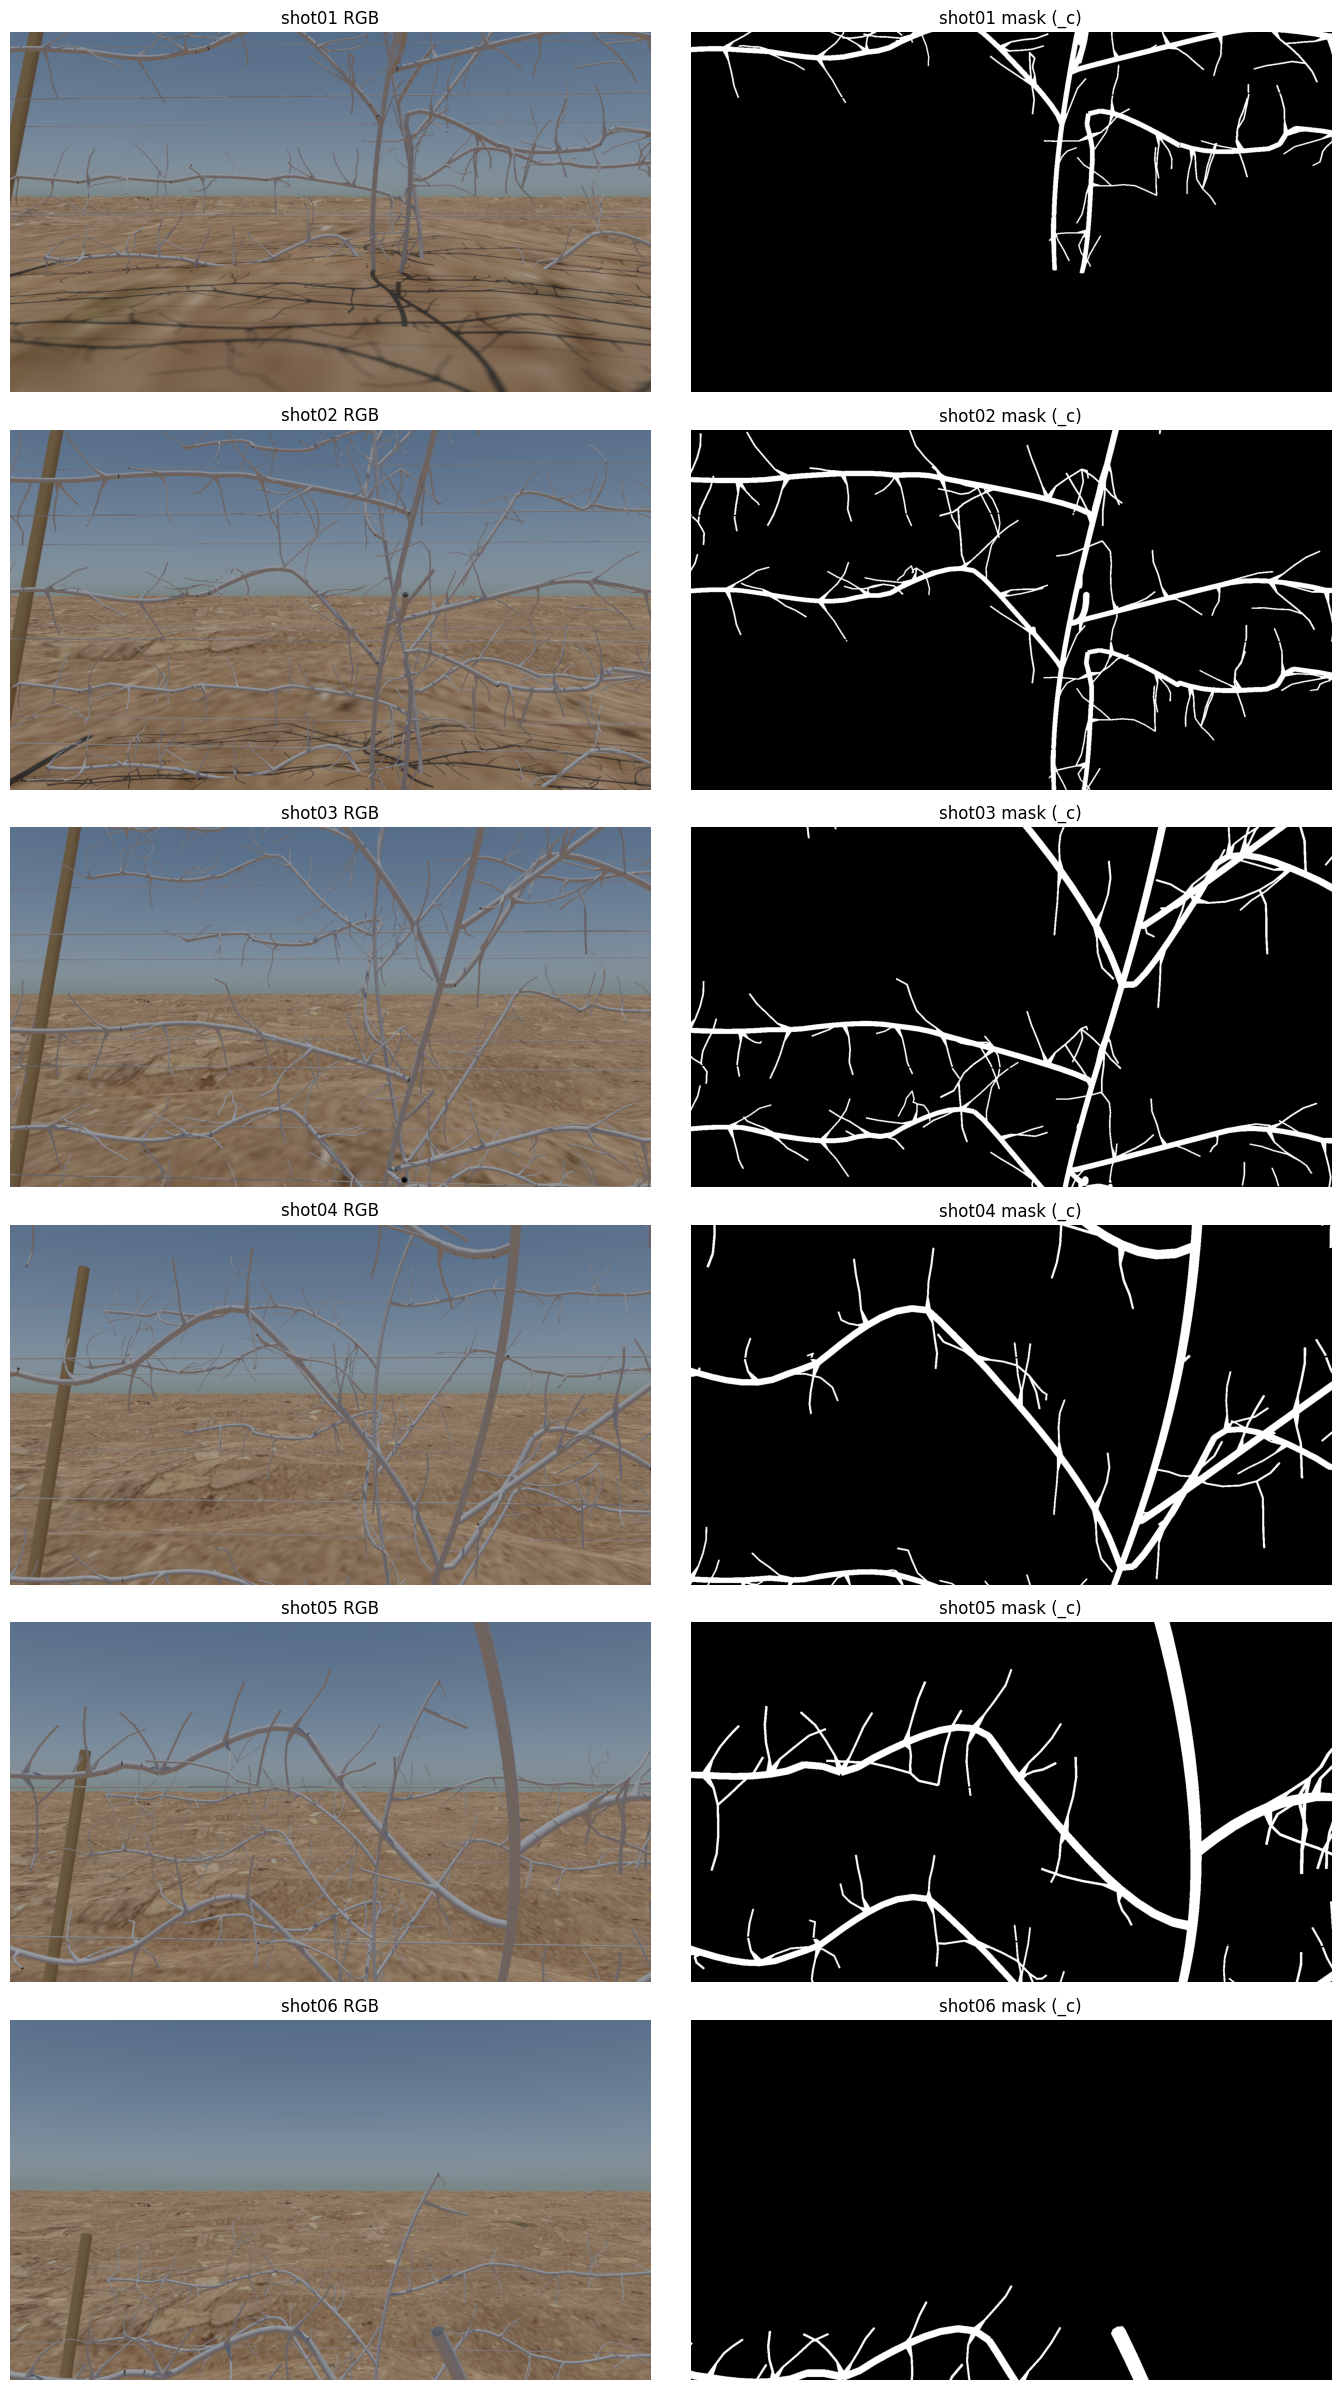

In [ ]:
# Config: center-shot RGB + mask side-by-side
import os
import glob
import matplotlib.pyplot as plt

DATA_ROOT = "../Data"  # or "/home/joses/Ag_Cv/Data"
TEXTURE = "bark_brown"
TREE_ID = "lpy_envy_00007"
NUM_SHOTS = 6

rgb_dir = os.path.join(DATA_ROOT, "rgb_5", TEXTURE, TREE_ID)
mask_dir = os.path.join(DATA_ROOT, "mask_5", TEXTURE, TREE_ID)

fig, axes = plt.subplots(NUM_SHOTS, 2, figsize=(14, 4 * NUM_SHOTS))
for i in range(1, NUM_SHOTS + 1):
    shot = f"shot{i:02d}"
    rgb_path = os.path.join(rgb_dir, f"{TREE_ID}_{shot}.png")
    # Mask: *_shot0X_c_*_tree_*.png (e.g. lpy_envy_00024_shot01_c_tree_0001.png)
    pattern = os.path.join(mask_dir, f"{TREE_ID}_{shot}_c_*.png")
    mask_files = sorted(glob.glob(pattern))
    mask_path = mask_files[0] if mask_files else None
    ax_rgb, ax_mask = axes[i - 1, 0], axes[i - 1, 1]
    if os.path.isfile(rgb_path):
        ax_rgb.imshow(plt.imread(rgb_path))
    else:
        ax_rgb.text(0.5, 0.5, f"Missing\n{rgb_path}", ha="center", va="center")
    ax_rgb.set_title(f"{shot} RGB")
    ax_rgb.axis("off")
    if mask_path and os.path.isfile(mask_path):
        ax_mask.imshow(plt.imread(mask_path), cmap="gray")
    else:
        ax_mask.text(0.5, 0.5, f"Missing\n{pattern}", ha="center", va="center")
    ax_mask.set_title(f"{shot} mask (_c)")
    ax_mask.axis("off")
plt.tight_layout()
plt.show()